# 1. Dataset

In [1]:
# Instalar kagglehub (pin 0.3.13: la 1.0.x rompe con kagglesdk 0.1.25)
import sys
!{sys.executable} -m pip install -q "kagglehub==0.3.13"


zsh:1: no such file or directory: /Users/99/2026-1/Tópicos


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import PIL.Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import kagglehub

print("TF version:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))


TF version: 2.21.0
GPU disponible: []


In [3]:
# Descargar dataset Intel Image Classification desde Kaggle
DATASET_PATH = Path(kagglehub.dataset_download("puneet6060/intel-image-classification"))

TRAIN_DIR = DATASET_PATH / "seg_train" / "seg_train"
TEST_DIR  = DATASET_PATH / "seg_test"  / "seg_test"
PRED_DIR  = DATASET_PATH / "seg_pred"  / "seg_pred"

print("Train:", TRAIN_DIR)
print("Test :", TEST_DIR)
print("Pred :", PRED_DIR)

CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClases ({NUM_CLASSES}):", CLASS_NAMES)


100%|██████████| 346M/346M [01:27<00:00, 4.13MB/s] 

Extracting files...


Train: /Users/99/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_train/seg_train
Test : /Users/99/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_test/seg_test
Pred : /Users/99/.cache/kagglehub/datasets/puneet6060/intel-image-classification/versions/2/seg_pred/seg_pred

Clases (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# 1.1 Carga y exploracion del dataset

In [4]:
# Conteo de imágenes por clase y por split
def count_images_per_class(root: Path) -> dict:
    return {c: len(list((root / c).glob("*.jpg"))) for c in CLASS_NAMES}

train_counts = count_images_per_class(TRAIN_DIR)
test_counts  = count_images_per_class(TEST_DIR)
n_pred       = len(list(PRED_DIR.glob("*.jpg")))

counts_df = pd.DataFrame({"train": train_counts, "test": test_counts})
counts_df.loc["TOTAL"] = counts_df.sum()
print(f"seg_pred (sin etiquetas): {n_pred} imágenes\n")
counts_df


seg_pred (sin etiquetas): 7301 imágenes



,train,test
buildings,2191,437
forest,2271,474
glacier,2404,553
mountain,2512,525
sea,2274,510
street,2382,501
TOTAL,14034,3000


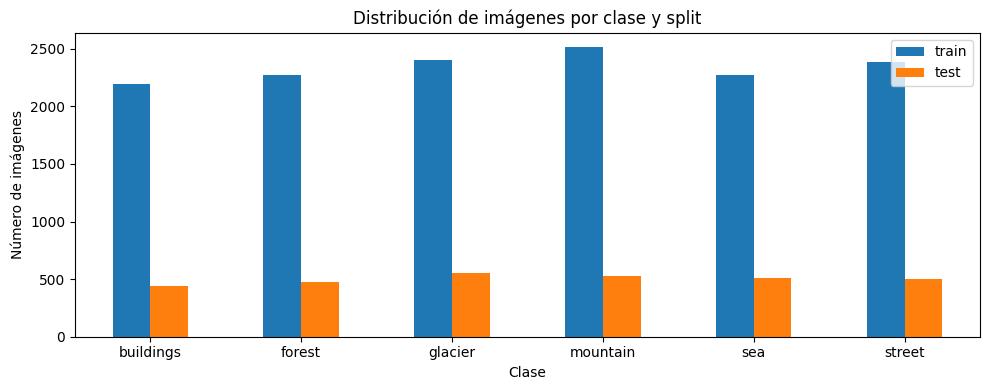

In [5]:
# Distribución de clases (¿está balanceado?)
fig, ax = plt.subplots(figsize=(10, 4))
counts_df.drop("TOTAL").plot(kind="bar", ax=ax)
ax.set_title("Distribución de imágenes por clase y split")
ax.set_ylabel("Número de imágenes")
ax.set_xlabel("Clase")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# Resolución original de las imágenes (muestreo de las primeras 50 por clase)
sample_resolutions = []
for c in CLASS_NAMES:
    for img_path in list((TRAIN_DIR / c).glob("*.jpg"))[:50]:
        with PIL.Image.open(img_path) as im:
            sample_resolutions.append(im.size)  # (width, height)

res_df = pd.DataFrame(sample_resolutions, columns=["width", "height"])
print("Resoluciones únicas encontradas:")
print(res_df.value_counts().head(10))
print(f"\nResolución dominante: {res_df.value_counts().idxmax()}")


Resoluciones únicas encontradas:
width  height
150    150       298
       115         1
       111         1
Name: count, dtype: int64

Resolución dominante: (np.int64(150), np.int64(150))


In [7]:
# Cargar datasets con tf.keras.utils.image_dataset_from_directory
# Usamos validation_split=0.2 sobre seg_train; seg_test queda como test set.
IMG_SIZE   = (150, 150)
BATCH_SIZE = 64
SEED       = 42

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=0.2,
    subset="training",
)

val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    validation_split=0.2,
    subset="validation",
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="categorical",
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Conteo exacto de elementos por split
n_train = tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE
n_val   = tf.data.experimental.cardinality(val_ds).numpy() * BATCH_SIZE
n_test  = tf.data.experimental.cardinality(test_ds).numpy() * BATCH_SIZE
print(f"\nAprox. — Train: {n_train}, Val: {n_val}, Test: {n_test}")


Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.

Aprox. — Train: 11264, Val: 2816, Test: 3008


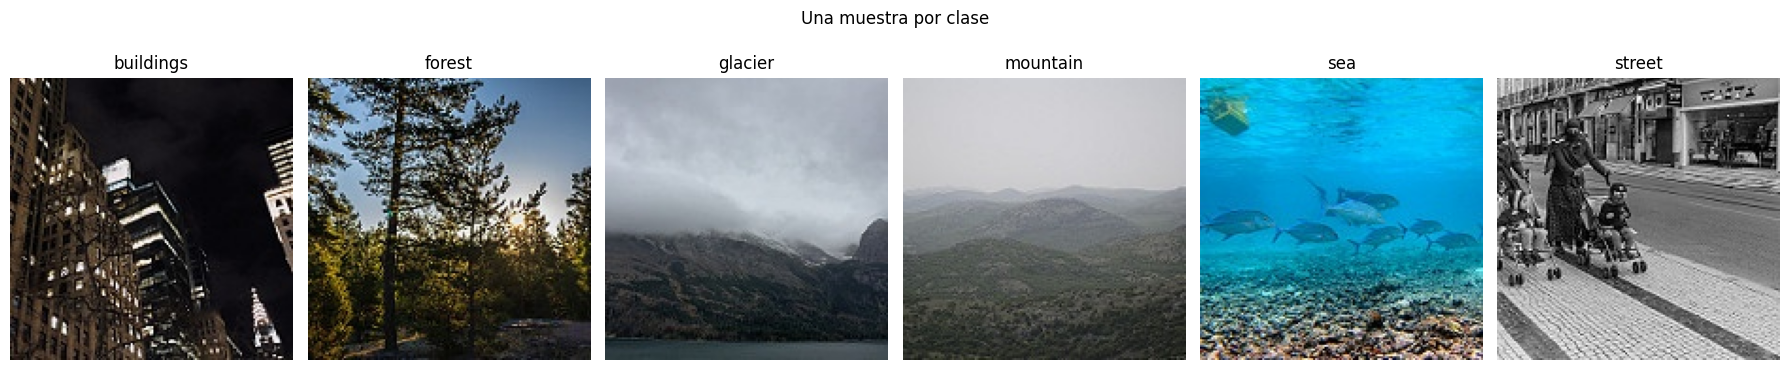

In [8]:
# Una imagen representativa de cada clase
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(3 * NUM_CLASSES, 3.5))
for ax, cls in zip(axes, CLASS_NAMES):
    img_path = next((TRAIN_DIR / cls).glob("*.jpg"))
    ax.imshow(PIL.Image.open(img_path))
    ax.set_title(cls, fontsize=12)
    ax.axis("off")
plt.suptitle("Una muestra por clase", y=1.05)
plt.tight_layout()
plt.show()


In [ ]:
# Grid 4x4 con variabilidad intra-clase — leemos directo con PIL para evitar
# bloqueos del pipeline tf.data en CPU/macOS.
import random
random.seed(SEED)

# Junto 16 paths aleatorios balanceados entre clases (≈3 por clase)
sample_paths = []
for cls in CLASS_NAMES:
    cls_paths = list((TRAIN_DIR / cls).glob("*.jpg"))
    sample_paths.extend([(p, cls) for p in random.sample(cls_paths, k=3)])
random.shuffle(sample_paths)
sample_paths = sample_paths[:16]

plt.figure(figsize=(12, 12))
for i, (img_path, cls) in enumerate(sample_paths):
    ax = plt.subplot(4, 4, i + 1)
    with PIL.Image.open(img_path) as im:
        plt.imshow(im)
    plt.title(cls)
    plt.axis("off")
plt.tight_layout()
plt.show()


1. ¿Cuantas imagenes existen en entrenamiento, validacion y prueba?
2. ¿Cual es la resolucion original de las imagenes?
3. ¿Por que este dataset es mas complejo que Fashion MNIST?
4. Identificar ejemplos donde dos clases parezcan visualmente similares.
5. ¿Que clases parecen mas difıciles de diferenciar?
6. ¿Que impacto tiene trabajar con tres canales de color?
7. ¿Que dificultades puede presentar este dataset para una MLP?

# 2. Preprocesamiento

1. Redimensionar todas las imagenes a una resolucion uniforme.
2. Comparar el impacto de utilizar:
  64 ×64
  128 ×128
  150 ×150
3. Normalizar las imagenes en el rango [0, 1].
4. Explicar por que la normalizacion es importante en Deep Learning.
5. Preparar una version flatten del dataset para utilizarla posteriormente en una MLP.
6. ¿Por que una CNN no requiere flatten al inicio?
7. Analizar el impacto de incrementar la resolucion de entrada sobre:
Tiempo de entrenamiento
Uso de memoria
Accuracy

# 3. Implementacion de una MLP

1. ¿Por que una MLP escala mal en imagenes complejas?
2. ¿Que evidencia de overfitting puede observarse?
3. ¿Como afecta el incremento de resolucion al numero de parametros?
4. ¿Que impacto tiene esto sobre el costo computacional?

# 4. Implementacion de una CNN

1. Explicar la funcion de las capas convolucionales.
2. Explicar que tipo de patrones aprende una CNN.
3. Explicar la funcion de MaxPooling.
4. ¿Por que las CNN preservan mejor la estructura espacial?
5. ¿Que representan los filtros convolucionales?
6. ¿Que impacto tiene el tamaño del kernel?
7. ¿Que impacto tiene incrementar el numero de filtros?
8. ¿Por que una CNN suele obtener mejor accuracy que una MLP en imagenes?
9. ¿Que impacto tiene agregar mas capas convolucionales?
10. ¿Que relacion existe entre profundidad y capacidad de representacion?

# 5. Entrenamiento y Evaluacion

# 6. Optimizacion del Modelo

# 7. Actividad de Investigacion
